## Question 4: Evaluating the Position of Women in the Global Labor Force: Participation Rates, Employment Structure, and the Impact of Education

### 4.1. Analytical Objectives

This analysis aims to measure and comprehensively evaluate the position of women in the global labor market across 3 main dimensions:
1. **Participation Trends:** Compare the gap in labor force participation rates between men and women over time.
2. **Employment Structure Shift:** Evaluate whether the shift in female employment (Agriculture $\rightarrow$ Industry $\rightarrow$ Services) leads to an increase in the proportion of wage and salaried workers (stable jobs).
3. **Impact of Education on Employment Risk:** Test the hypothesis that universalizing tertiary education helps women escape vulnerable employment.

#### 4.1.1. SMART Criteria for the Analysis
* **S (Specific):** Evaluate the evolution of women's economic empowerment by analyzing gender participation gaps, sectoral employment shifts, and the protective role of higher education against informal labor.
* **M (Measurable):** Quantified using specific World Bank indicators including labor force participation rates, sectoral distribution percentages (agriculture, industry, services), salaried worker rates, and vulnerable employment percentages.
* **A (Achievable):** Successfully executed utilizing the robust, continuous, and cleaned dataset for the selected representative countries.
* **R (Relevant):** Crucial for determining whether macroeconomic growth and educational access actively translate into formal, stable, and equitable economic participation for women.
* **T (Time-bound):** The analysis spans the comprehensive 25-year historical timeframe from **2000 to 2024**.

---

### 4.2. Data Fields Used

**Group 1: Labor Force Participation Rate**
* **`SL.TLF.CACT.FE.ZS`** - Labor force participation rate, female (% of female population ages 15+)
* **`SL.TLF.CACT.MA.ZS`** - Labor force participation rate, male (% of male population ages 15+)
  * *Meaning:* Measures the proportion of the population ages 15 and older that is economically active. The male rate is used as a global baseline to compare the gender gap.

**Group 2: Employment Structure and Stability**
* **`SL.AGR.EMPL.FE.ZS` / `SL.IND.EMPL.FE.ZS` / `SL.SRV.EMPL.FE.ZS`** - Employment in agriculture/industry/services, female (% of female employment)
  * *Meaning:* Shows the distribution of the female workforce across three economic sectors: Agriculture, Industry, and Services.
* **`SL.EMP.WORK.FE.ZS`** - Wage and salaried workers, female (% of female employment)
  * *Meaning:* The percentage of women working as wage and salaried workers (formal sector, with contracts and stable income).

**Group 3: Education and Employment Risk**
* **`SE.TER.ENRR.FE`** - School enrollment, tertiary, female (% gross)
  * *Meaning:* The gross enrollment ratio of females in tertiary education.
* **`SL.EMP.VULN.FE.ZS`** - Vulnerable employment, female (% of female employment)
  * *Meaning:* The percentage of female workers in vulnerable employment (own-account workers and contributing family workers). This serves as a direct measure of "employment risk".

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')


DATA_PATH = 'data3/dataset.csv'
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# Danh sách các chỉ số cần dùng cho Câu hỏi 4
LABOR_INDICATORS = [
    'SL.TLF.CACT.FE.ZS', 'SL.TLF.CACT.MA.ZS', 
    'SL.AGR.EMPL.FE.ZS', 'SL.IND.EMPL.FE.ZS', 'SL.SRV.EMPL.FE.ZS', 
    'SL.EMP.WORK.FE.ZS', 'SE.TER.ENRR.FE', 'SL.EMP.VULN.FE.ZS'
]


labor_df = df_raw[df_raw['Series Code'].isin(LABOR_INDICATORS)].copy()


year_cols = [c for c in labor_df.columns if c.startswith('20') and c.endswith(']')]
labor_long = labor_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)


labor_long['Year'] = labor_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
labor_long['Value'] = pd.to_numeric(labor_long['Value'], errors='coerce')
labor_long = labor_long[labor_long['Year'] <= 2024].reset_index(drop=True)


SELECTED_COUNTRIES = ['NGA', 'RWA', 'SWE', 'USA', 'VNM', 'JPN']
labor_6_countries = labor_long[labor_long['Country Code'].isin(SELECTED_COUNTRIES)].copy()

labor_6_countries['Value'] = labor_6_countries.groupby(['Country Code', 'Series Code'])['Value'].transform(lambda x: x.interpolate(method='linear').ffill().bfill())


print(f"Số giá trị hợp lệ (6 quốc gia): {len(labor_6_countries)}")
print(f"Năm có dữ liệu: {sorted(labor_6_countries['Year'].unique())}")
print(f"Số ô bị thiếu dữ liệu (NaN): {labor_6_countries['Value'].isna().sum()}")


Số giá trị hợp lệ (6 quốc gia): 1350
Năm có dữ liệu: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Số ô bị thiếu dữ liệu (NaN): 0


### 4.3. Detailed Analysis

#### 4.3.1. Labor Force Participation Trends: Females vs. Males

**Chart Type:** Multi-line chart comparing the female labor force participation rate across the 6 representative countries, combined with a Baseline representing the global male average.

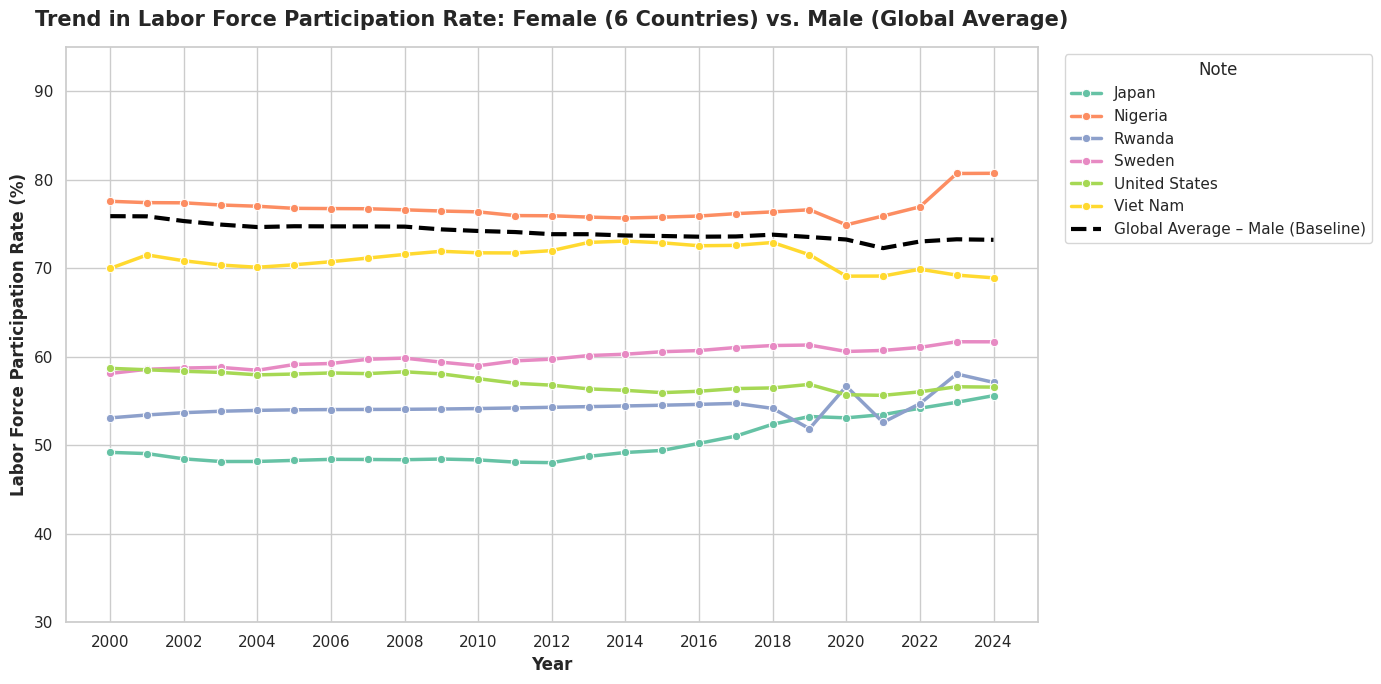

In [7]:

plt.figure(figsize=(14, 7))

# Tính trung bình toàn cầu cho Nam giới 
global_male_lfpr = labor_long[labor_long['Series Code'] == 'SL.TLF.CACT.MA.ZS'].groupby('Year')['Value'].mean().reset_index()

# Nữ giới của 6 quốc gia
female_lfpr_6c = labor_6_countries[labor_6_countries['Series Code'] == 'SL.TLF.CACT.FE.ZS']

# Vẽ đường cho 6 quốc gia (Nữ)
sns.lineplot(
    data=female_lfpr_6c, x='Year', y='Value', hue='Country Name', 
    marker='o', markersize=6, palette='Set2', linewidth=2.5
)

# Vẽ đường Baseline Trung bình Toàn cầu (Nam)
sns.lineplot(
    data=global_male_lfpr, x='Year', y='Value', 
    color='black', linestyle='--', linewidth=3, label='Global Average – Male (Baseline)'
)

plt.title('Trend in Labor Force Participation Rate: Female (6 Countries) vs. Male (Global Average)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Labor Force Participation Rate (%)', fontsize=12, fontweight='bold')
plt.xticks(range(2000, 2025, 2))
plt.ylim(30, 95)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Note', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Chart 1 Observations:**
* **Global Male Baseline (Dashed Black Line):** Remained highly stable (around 73-75%) over the two decades, indicating consistent economic participation by men globally.
* **Nigeria and Viet Nam:** Nigeria records the highest female labor participation rate (ranging from 75% to over 80% recently), consistently surpassing the global male average. Viet Nam follows closely, maintaining a high and stable rate of around 70-72%.
* **Sweden, USA, Japan, and Rwanda:** These countries cluster in the 50-60% range. Notably, Japan shows a steady upward trend from 2012 onwards, reflecting the success of policies designed to bring women back into the workforce. Conversely, the United States displays a slow but gradual decline in female participation over the same 24-year period.

#### 4.3.2. Female Participation Gap to Global Male Baseline (2024)

**Chart Type:** Dumbbell Plot comparing the female labor force participation rate of 6 selected countries against the global male baseline (73.2%) in 2024.

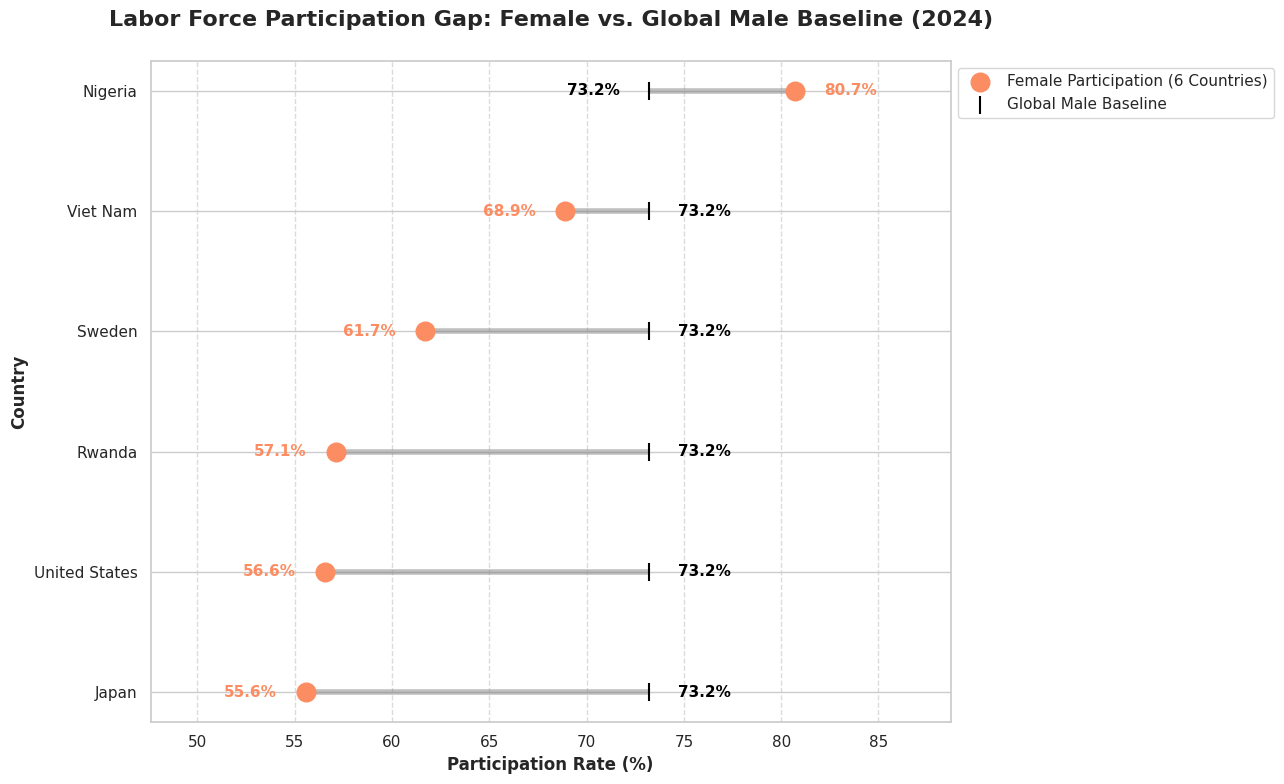

In [8]:
    # 4.3.2. Dumbbell Plot: Female Participation Gap to Global Male Baseline (2024)
    latest_year = 2024
    female_2024 = female_lfpr_6c[female_lfpr_6c['Year'] == latest_year].set_index('Country Name')['Value']
    male_baseline_2024 = global_male_lfpr[global_male_lfpr['Year'] == latest_year]['Value'].values[0]

    df_dumbbell = female_2024.sort_values().reset_index()
    df_dumbbell['Male Baseline'] = male_baseline_2024

    plt.figure(figsize=(13, 8))

    plt.hlines(y=df_dumbbell['Country Name'], xmin=df_dumbbell[['Value', 'Male Baseline']].min(axis=1), 
            xmax=df_dumbbell[['Value', 'Male Baseline']].max(axis=1), 
            color='grey', alpha=0.5, linewidth=4, zorder=1)

    # Vẽ điểm dữ liệu Nữ giới của 6 quốc gia
    plt.scatter(df_dumbbell['Value'], df_dumbbell['Country Name'], 
                color='#FC8D62', s=180, label='Female Participation (6 Countries)', zorder=3)

    # Vẽ điểm dữ liệu Nam giới (Global Baseline)
    plt.scatter(df_dumbbell['Male Baseline'], df_dumbbell['Country Name'], 
                color='black', s=180, label='Global Male Baseline', marker='|', zorder=3)


    plt.title(f'Labor Force Participation Gap: Female vs. Global Male Baseline ({latest_year})', 
            fontsize=16, fontweight='bold', pad=25)
    plt.xlabel('Participation Rate (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Country', fontsize=12, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.legend(frameon=True, fontsize=11, loc='upper left', bbox_to_anchor=(1, 1))


    min_val = df_dumbbell[['Value', 'Male Baseline']].min().min()
    max_val = df_dumbbell[['Value', 'Male Baseline']].max().max()
    plt.xlim(min_val - 8, max_val + 8)


    offset = 1.5
    for i, row in df_dumbbell.iterrows():
        ha_f = 'right' if row['Value'] <= row['Male Baseline'] else 'left'
        x_f = row['Value'] - offset if row['Value'] <= row['Male Baseline'] else row['Value'] + offset
        plt.text(x_f, row['Country Name'], f"{row['Value']:.1f}%", 
                va='center', ha=ha_f, color='#FC8D62', fontweight='bold', fontsize=11)

        ha_m = 'left' if row['Male Baseline'] > row['Value'] else 'right'
        x_m = row['Male Baseline'] + offset if row['Male Baseline'] > row['Value'] else row['Male Baseline'] - offset
        plt.text(x_m, row['Country Name'], f"{row['Male Baseline']:.1f}%", 
                va='center', ha=ha_m, color='black', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()

#### 4.3.3. Shift in Employment Structure and Wage/Salaried Rates (Global Average)

**Chart Type:** Stacked Area Chart illustrating the agriculture-industry-services composition, overlaid with a Line Chart showing the percentage of female wage and salaried workers.

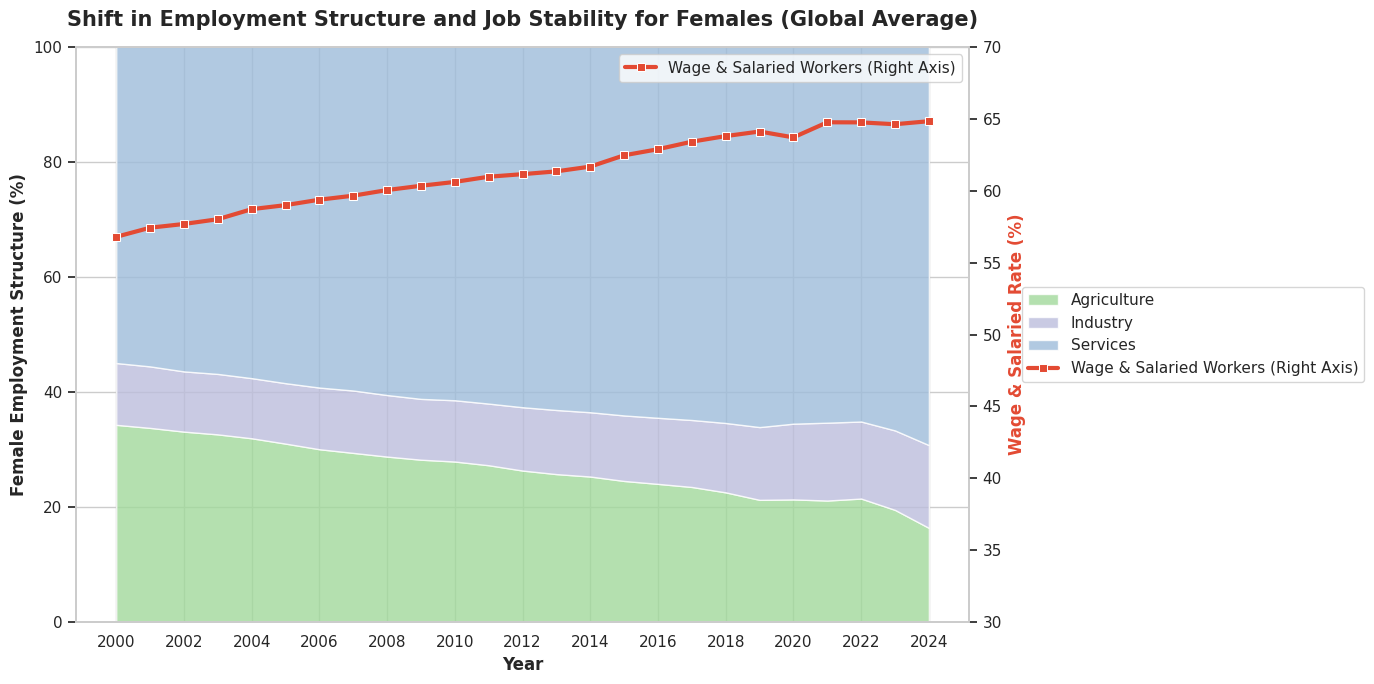

In [9]:
sectors = ['SL.AGR.EMPL.FE.ZS', 'SL.IND.EMPL.FE.ZS', 'SL.SRV.EMPL.FE.ZS', 'SL.EMP.WORK.FE.ZS']

global_structure = labor_long[labor_long['Series Code'].isin(sectors)].groupby(['Year', 'Series Code'])['Value'].mean().unstack().reset_index()


for sector in sectors:
    if sector not in global_structure.columns:
        global_structure[sector] = 0

global_structure = global_structure.dropna()

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.stackplot(global_structure['Year'], 
              global_structure['SL.AGR.EMPL.FE.ZS'], 
              global_structure['SL.IND.EMPL.FE.ZS'], 
              global_structure['SL.SRV.EMPL.FE.ZS'], 
              labels=['Agriculture', 'Industry', 'Services'], 
              colors=['#a1d99b', '#bcbddc', '#9ebcda'], alpha=0.8)

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Female Employment Structure (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_xticks(range(2000, 2025, 2))

# Trục 2: Vẽ Line Chart cho Wage and Salaried workers
ax2 = ax1.twinx()
sns.lineplot(data=global_structure, x='Year', y='SL.EMP.WORK.FE.ZS', 
             color='#e34a33', marker='s', linewidth=3, ax=ax2, label='Wage & Salaried Workers (Right Axis)')

ax2.set_ylabel('Wage & Salaried Rate (%)', fontsize=12, fontweight='bold', color='#e34a33')
ax2.set_ylim(30, 70) 
ax2.grid(False) 

# Combine Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left', bbox_to_anchor=(1.05, 0.5))

plt.title('Shift in Employment Structure and Job Stability for Females (Global Average)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



**Chart 2 Observations:**
* **Dominance and Expansion of the Services Sector:** The blue area (Services) consistently expands over the years, eating heavily into the Agriculture sector (green area), which shrinks from over 30% down to roughly 15%. The Industrial sector (purple) remains relatively thin and stagnant. This highlights a global urbanization trend pulling women from the fields into the service economy.
* **Correlation with Job Stability:** The red line (Wage and Salaried Workers) trends upward from under 60% to approximately 65%, moving in parallel with the growth of the services sector. This structural shift has brought a positive impact: Women are transitioning from self-sufficient rural labor to contracted, salaried positions, thereby increasing their financial independence.

#### 4.3.4. Impact of Tertiary Education on Female Employment Risk

**Chart Type:** Grouped Bar Chart comparing Tertiary Enrollment (blue bars) and Vulnerable Employment (red bars) for females in representative countries from 2000 to 2024.

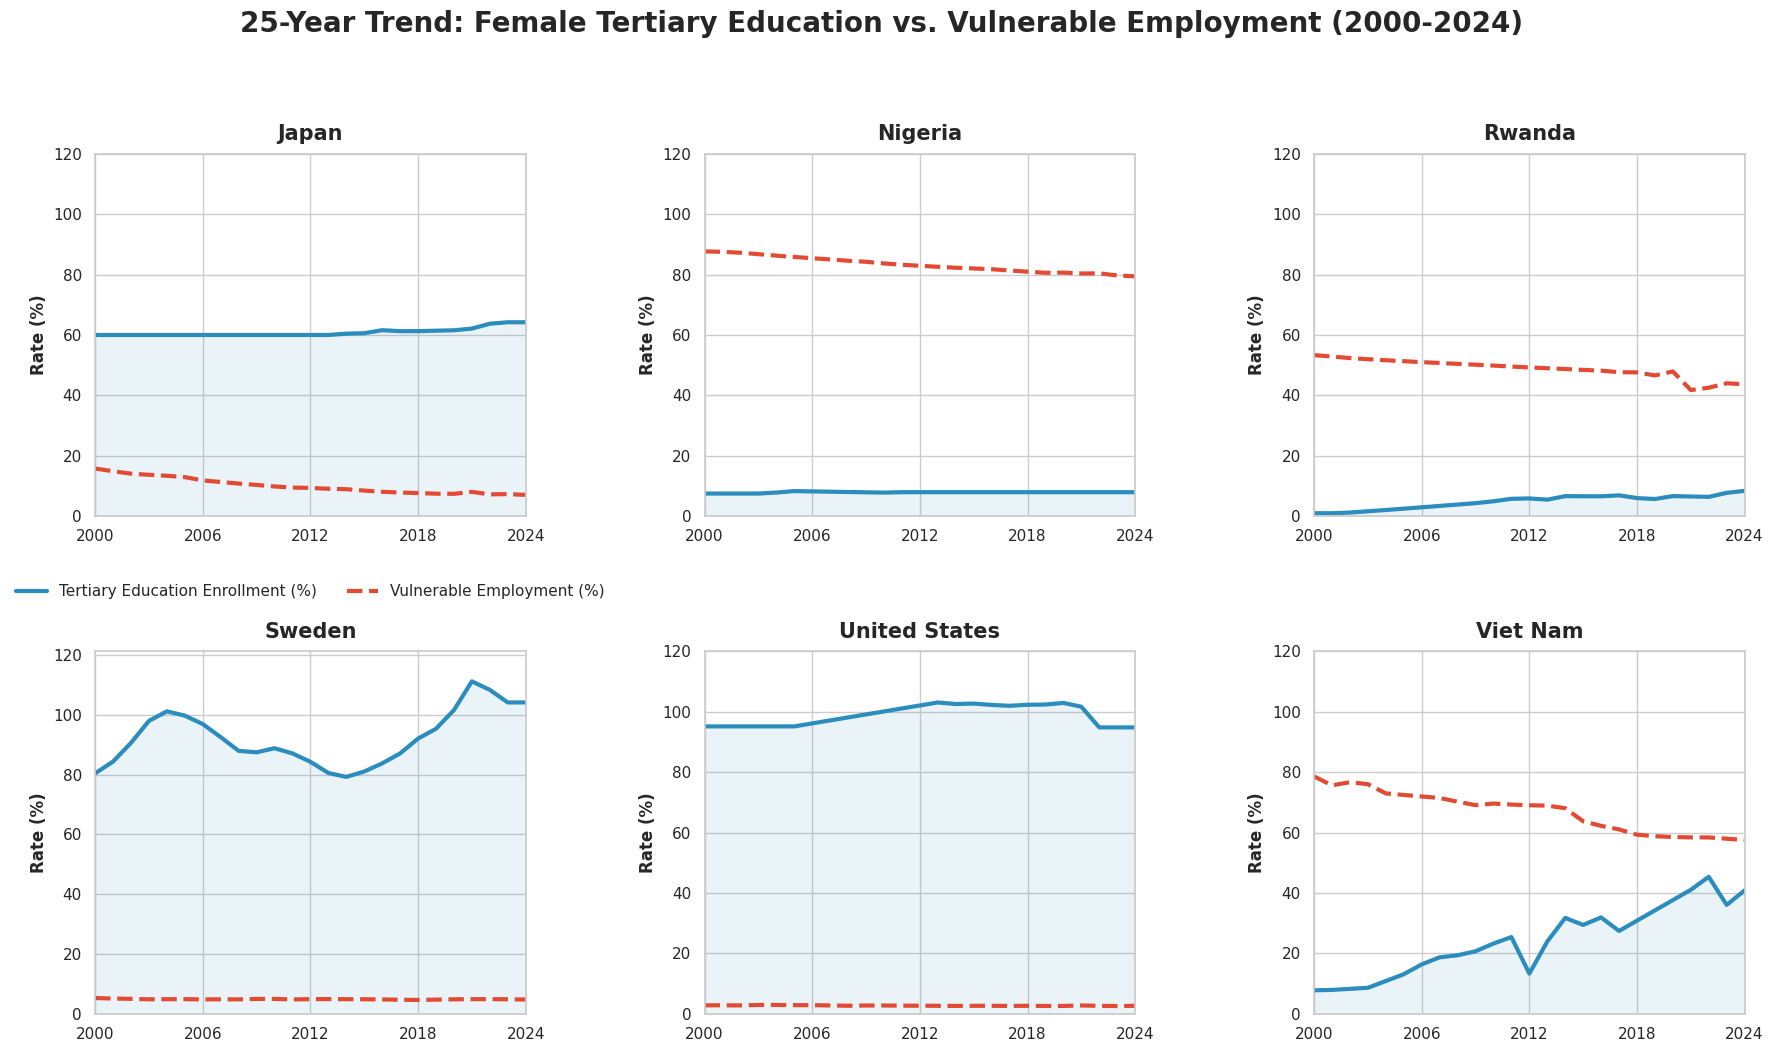

In [10]:
INDICATORS = {
    'SE.TER.ENRR.FE': 'Tertiary_Edu',
    'SL.EMP.VULN.FE.ZS': 'Vulnerable_Emp'
}

edu_vuln_df = labor_long[labor_long['Series Code'].isin(INDICATORS.keys())].copy()

# Xóa trùng lặp
edu_vuln_df = edu_vuln_df.drop_duplicates(subset=['Country Name', 'Country Code', 'Series Code', 'Year'])

edu_vuln_df['Value'] = edu_vuln_df.groupby(['Country Name', 'Series Code'])['Value'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))


# Pivot data theo Năm (2000 - 2024)
pivot_trend = edu_vuln_df.pivot_table(index=['Country Name', 'Year'], 
                                      columns='Series Code', 
                                      values='Value', aggfunc='mean').reset_index()

pivot_trend.rename(columns=INDICATORS, inplace=True)
pivot_trend = pivot_trend.dropna(subset=['Tertiary_Edu', 'Vulnerable_Emp'])

# 2. Vẽ Lưới 6 Subplots
countries = pivot_trend['Country Name'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('25-Year Trend: Female Tertiary Education vs. Vulnerable Employment (2000-2024)', 
             fontsize=20, fontweight='bold', y=1.05)
axes = axes.flatten()

color_edu = '#2b8cbe'  # Xanh dương: Đại học
color_vuln = '#e34a33' # Đỏ: Việc làm tổn thương

for i, country in enumerate(countries):
    ax = axes[i]
    country_data = pivot_trend[pivot_trend['Country Name'] == country].sort_values('Year')
    
    # Vẽ đường Giáo dục Đại học
    line1, = ax.plot(country_data['Year'], country_data['Tertiary_Edu'], 
                     color=color_edu, linewidth=3, label='Tertiary Education Enrollment (%)')
    ax.fill_between(country_data['Year'], country_data['Tertiary_Edu'], color=color_edu, alpha=0.1)
    
    # Vẽ đường Việc làm dễ tổn thương
    line2, = ax.plot(country_data['Year'], country_data['Vulnerable_Emp'], 
                     color=color_vuln, linewidth=3, linestyle='--', label='Vulnerable Employment (%)')
    
    ax.set_title(country, fontsize=15, fontweight='bold', pad=10)
    ax.set_ylabel('Rate (%)', fontweight='bold')
    ax.set_ylim(0, max(120, country_data['Tertiary_Edu'].max() + 10)) # Trục Y chung từ 0 đến max
    ax.set_xlim(2000, 2024)
    ax.set_xticks([2000, 2006, 2012, 2018, 2024])
    
    if i == 0:
        ax.legend(handles=[line1, line2], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

**Chart 3 Observations:**

**1. Overview: The "Scissor Effect"**
Looking at the 25-year timeline, we can observe a stark inverse correlation between the two indicators. As the solid blue line (Tertiary Education) climbs, the dashed red line (Vulnerable Employment) is consistently driven down. This demonstrates that advanced education serves as the ultimate "ticket" for women to escape precarious, informal labor (such as subsistence farming or petty trade) and transition into the formal sector with stable contracts and salaries.

**2. Clustering Analysis (The 3 Country Profiles):**
* **The "Ceiling & Floor" Economies (US, Sweden, Japan):** Throughout the two decades, their female higher education rates have consistently hit the "ceiling" (ranging from 60% to over 100%), which in turn crushes the vulnerable employment rate to the "floor" (stabilized below 10%). In these developed nations, women are largely shielded from informal, high-risk work thanks to a robust knowledge-based foundation.
* **The "Active Transformation" (Viet Nam):** Viet Nam's chart most vividly illustrates the "X-shaped" structural shift. From 2000 to 2024, female tertiary enrollment skyrocketed from under 10% to over 40%. Simultaneously, vulnerable employment plummeted from nearly 80% to under 60%. This clearly reflects a new generation of women migrating from agricultural fields into corporate, manufacturing, and service sectors.
* **The "Informal Labor Trap" (Nigeria, Rwanda):** While Rwanda shows early signs of structural improvement, Nigeria represents a critical warning. Its female tertiary enrollment has flatlined at the bottom (under 10%) for two decades, leaving the vulnerable employment rate trapped at a staggering 80%+. Without access to higher education, breaking the cycle of informal labor remains virtually impossible.

**3. Key Takeaway:**
Investing in female tertiary education is far more than a social "Gender Parity" initiative; it is a profound **macroeconomic lever**. It actively restructures the labor market, permanently transitioning the female workforce from a state of "high-vulnerability, low-productivity" to "formal, high-productivity" employment.

### 4.4. General Conclusions and Limitations

**4.4.1. General Conclusions**
Synthesizing the three analyses above, we can draw a comprehensive picture of the female labor force:
* Although the female labor force participation rate still varies drastically by region (and generally lags behind men), the **quality** of their employment is improving over time globally, driven by a massive shift away from agriculture into the services sector.
* **Education is the vital key.** In the labor market, a higher education degree is an almost absolute guarantee for women to escape risky, unpaid, or precarious work (as proven by the stark contrasts in Chart 3). 

**4.4.2. Limitations of the Analysis**
* The `Labor Force Participation Rate` statistic **completely overlooks unpaid domestic labor.** Women staying home to care for children and manage households handle a massive workload that sustains the economy, yet statistically, they are classified as "economically inactive."
* The `Wage and salaried workers` indicator merely counts those with formal contracts but **fails to reflect the Gender Wage Gap.** Women may hold formal office positions identical to men but still receive lower compensation for the exact same role.